# Quiz 1: Major Ions

### Plot a vertical profile of chlorine for the Atlantic and Pacific.

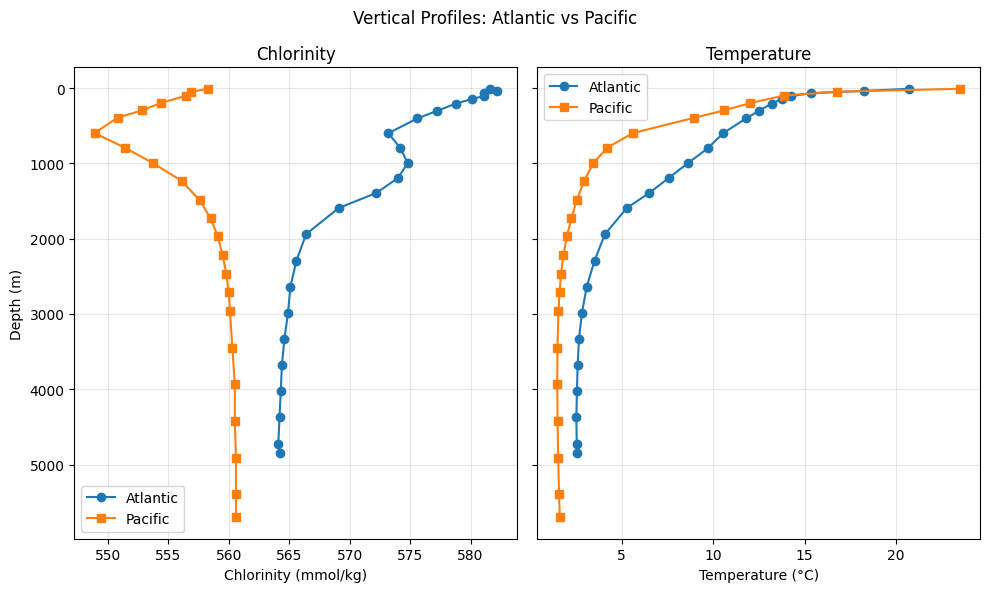

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load profile data
atlantic = pd.read_csv('Data/Atlantic_Cl.txt')
pacific = pd.read_csv('Data/Pacific_Cl.txt')

# Side-by-side vertical profiles: chlorinity (left) and temperature (right)
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Left panel: chlorinity
axes[0].plot(atlantic['Cl_mmol_per_kg'], atlantic['Depth_m'], marker='o', linestyle='-', label='Atlantic')
axes[0].plot(pacific['Cl_mmol_per_kg'], pacific['Depth_m'], marker='s', linestyle='-', label='Pacific')
axes[0].set_xlabel('Chlorinity (mmol/kg)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Chlorinity')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right panel: temperature
axes[1].plot(atlantic['Temp_C'], atlantic['Depth_m'], marker='o', linestyle='-', label='Atlantic')
axes[1].plot(pacific['Temp_C'], pacific['Depth_m'], marker='s', linestyle='-', label='Pacific')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_title('Temperature')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Depth increases downward in ocean profiles
axes[0].invert_yaxis()

fig.suptitle('Vertical Profiles: Atlantic vs Pacific', y=0.98)
plt.tight_layout()
plt.show()

### Plot the vertical profiles of Nitrate and Phosphate.

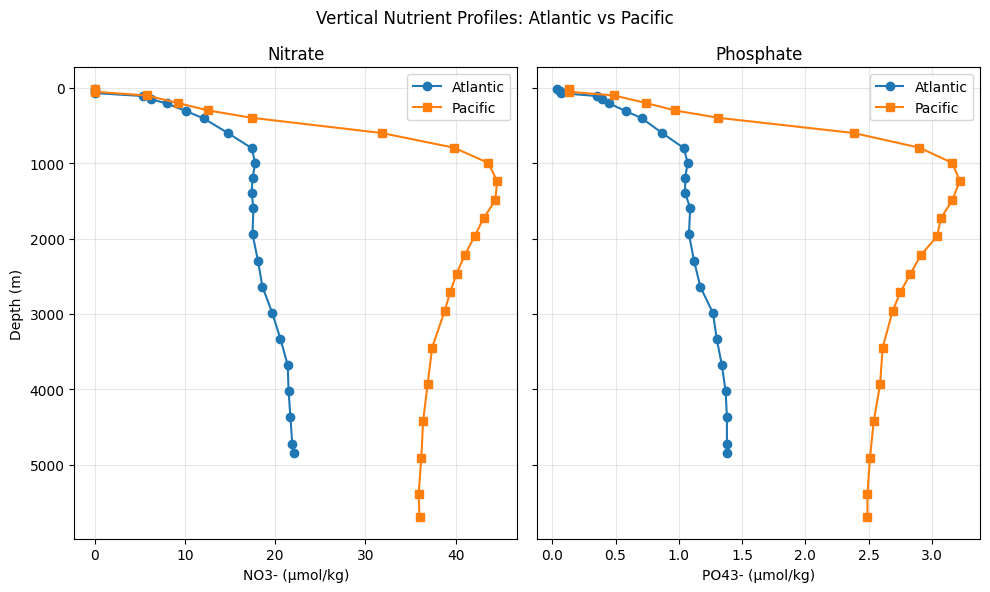

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load nutrient profile data
atlantic_np = pd.read_csv('Data/Atlantic_N_P.txt')
pacific_np = pd.read_csv('Data/Pacific_N_P.txt')

# Side-by-side vertical profiles: nitrate (left) and phosphate (right)
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Left panel: nitrate (NO3-)
axes[0].plot(atlantic_np['NO3_umol_per_kg'], atlantic_np['Depth_m'], marker='o', linestyle='-', label='Atlantic')
axes[0].plot(pacific_np['NO3_umol_per_kg'], pacific_np['Depth_m'], marker='s', linestyle='-', label='Pacific')
axes[0].set_xlabel('NO3- (μmol/kg)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Nitrate')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right panel: phosphate (PO43-)
axes[1].plot(atlantic_np['PO4_umol_per_kg'], atlantic_np['Depth_m'], marker='o', linestyle='-', label='Atlantic')
axes[1].plot(pacific_np['PO4_umol_per_kg'], pacific_np['Depth_m'], marker='s', linestyle='-', label='Pacific')
axes[1].set_xlabel('PO43- (μmol/kg)')
axes[1].set_title('Phosphate')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Depth increases downward in ocean profiles
axes[0].invert_yaxis()

fig.suptitle('Vertical Nutrient Profiles: Atlantic vs Pacific', y=0.98)
plt.tight_layout()
plt.show()

### Make a plot to assess if nitrate and phosphate are behaving conservatively. 

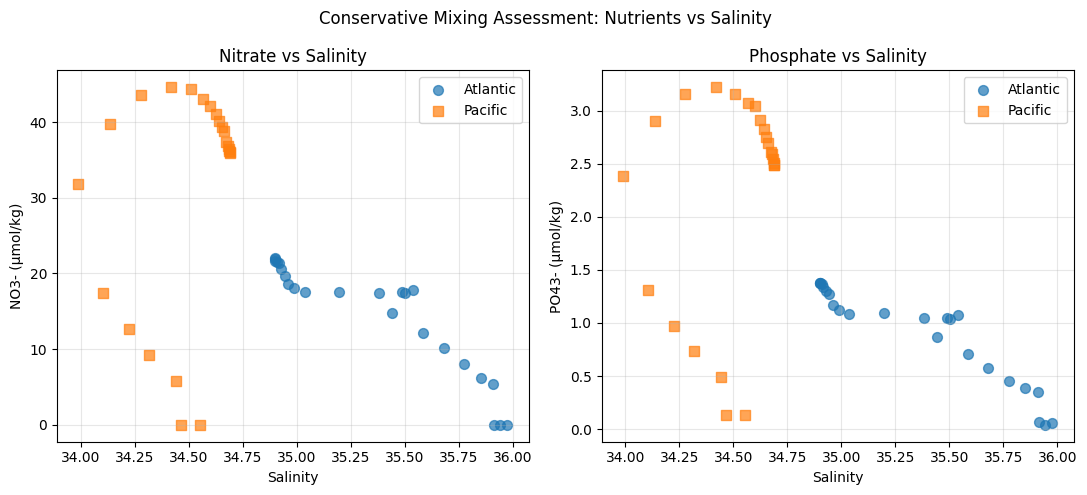

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load all data files - we need salinity from the chlorinity files
atlantic_all = pd.read_csv('Data/Atlantic_Cl.txt')
pacific_all = pd.read_csv('Data/Pacific_Cl.txt')
atlantic_np = pd.read_csv('Data/Atlantic_N_P.txt')
pacific_np = pd.read_csv('Data/Pacific_N_P.txt')

# Round depth values to nearest integer for matching
atlantic_all['Depth_m'] = np.round(atlantic_all['Depth_m'])
pacific_all['Depth_m'] = np.round(pacific_all['Depth_m'])
atlantic_np['Depth_m'] = np.round(atlantic_np['Depth_m'])
pacific_np['Depth_m'] = np.round(pacific_np['Depth_m'])

# Merge datasets on depth to combine salinity with nutrients
atlantic_merged = pd.merge(atlantic_all, atlantic_np, on='Depth_m', how='inner')
pacific_merged = pd.merge(pacific_all, pacific_np, on='Depth_m', how='inner')

# Side-by-side scatter plots: Nitrate vs Salinity (left) and Phosphate vs Salinity (right)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left panel: Nitrate vs Salinity
axes[0].scatter(atlantic_merged['Salinity'], atlantic_merged['NO3_umol_per_kg'], 
                marker='o', s=50, alpha=0.7, label='Atlantic')
axes[0].scatter(pacific_merged['Salinity'], pacific_merged['NO3_umol_per_kg'], 
                marker='s', s=50, alpha=0.7, label='Pacific')
axes[0].set_xlabel('Salinity')
axes[0].set_ylabel('NO3- (μmol/kg)')
axes[0].set_title('Nitrate vs Salinity')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right panel: Phosphate vs Salinity
axes[1].scatter(atlantic_merged['Salinity'], atlantic_merged['PO4_umol_per_kg'], 
                marker='o', s=50, alpha=0.7, label='Atlantic')
axes[1].scatter(pacific_merged['Salinity'], pacific_merged['PO4_umol_per_kg'], 
                marker='s', s=50, alpha=0.7, label='Pacific')
axes[1].set_xlabel('Salinity')
axes[1].set_ylabel('PO43- (μmol/kg)')
axes[1].set_title('Phosphate vs Salinity')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle('Conservative Mixing Assessment: Nutrients vs Salinity', y=0.98)
plt.tight_layout()
plt.show()

### Plot a graph to determine if copper is behaving conservatively

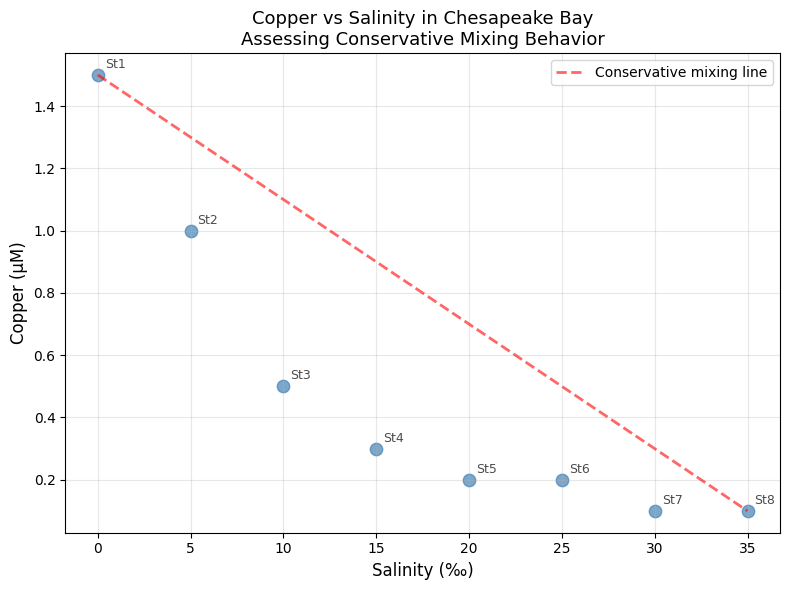

Conservative mixing assessment:
Freshwater endmember (S=0): Cu = 1.5 μM
Seawater endmember (S=35): Cu = 0.1 μM

If copper behaved conservatively, all points would fall on the red dashed line.
Points ABOVE the line = copper addition (non-conservative source)
Points BELOW the line = copper removal (non-conservative sink)


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Chesapeake Bay data
chesapeake = pd.read_csv('Data/ChesapeakeBay.txt')

# Plot Copper vs Salinity
plt.figure(figsize=(8, 6))
plt.scatter(chesapeake['Salinity_permil'], chesapeake['Copper_uM'], 
            marker='o', s=80, alpha=0.7, color='steelblue')

# Add station labels to points
for i, row in chesapeake.iterrows():
    plt.annotate(f"St{int(row['Station'])}", 
                 (row['Salinity_permil'], row['Copper_uM']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.7)

# If conservative, we'd expect a linear mixing line
# Plot theoretical conservative mixing line from freshwater to seawater
freshwater_Cu = chesapeake[chesapeake['Salinity_permil'] == 0]['Copper_uM'].values[0]
seawater_Cu = chesapeake[chesapeake['Salinity_permil'] == 35]['Copper_uM'].values[0]
salinity_range = np.array([0, 35])
conservative_line = np.array([freshwater_Cu, seawater_Cu])
plt.plot(salinity_range, conservative_line, 'r--', linewidth=2, 
         label=f'Conservative mixing line', alpha=0.6)

plt.xlabel('Salinity (‰)', fontsize=12)
plt.ylabel('Copper (μM)', fontsize=12)
plt.title('Copper vs Salinity in Chesapeake Bay\nAssessing Conservative Mixing Behavior', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print analysis
print("Conservative mixing assessment:")
print(f"Freshwater endmember (S=0): Cu = {freshwater_Cu} μM")
print(f"Seawater endmember (S=35): Cu = {seawater_Cu} μM")
print("\nIf copper behaved conservatively, all points would fall on the red dashed line.")
print("Points ABOVE the line = copper addition (non-conservative source)")
print("Points BELOW the line = copper removal (non-conservative sink)")